<a href="https://colab.research.google.com/github/ymuto0302/ML_Study_Session/blob/main/NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ナイーブベイズ (Naive Bayes)

In [1]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 27.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=5843714fbcf22b18f88432e82687c176939dfa4bb538821e36e5fe4d6fa268e5
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


## ガウシアンナイーブベイズ ─ 基本的な分類

In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# ──────────────────────
# データの準備
# ──────────────────────
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ──────────────────────
# モデルの構築と学習
# 注：ナイーブベイズはスケーリング不要
# ──────────────────────
gnb = GaussianNB(
    var_smoothing=1e-9   # 分散のフロア値（数値安定性のため）
)
gnb.fit(X_train, y_train)

# ──────────────────────
# 予測と評価
# ──────────────────────
y_pred = gnb.predict(X_test)

print(f"正解率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(
    y_test, y_pred, target_names=iris.target_names
))


正解率 (Accuracy): 0.9111

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



## 学習されたパラメータの確認 ─ 各クラスの平均と分散

In [3]:
print("=== ガウシアンナイーブベイズの学習パラメータ ===\n")

# 事前確率
print("【事前確率 P(C)】")
for name, prior in zip(iris.target_names, gnb.class_prior_):
    print(f"  {name:12s}: {prior:.4f}")
print()

# 各クラスの平均と分散
for c_idx, c_name in enumerate(iris.target_names):
    print(f"【クラス: {c_name}】")
    for f_idx, f_name in enumerate(iris.feature_names):
        mu = gnb.theta_[c_idx, f_idx]
        var = gnb.var_[c_idx, f_idx]
        print(f"  {f_name:20s}: μ = {mu:6.3f},  σ² = {var:6.3f}")
    print()

# → これらの μ と σ^2がガウス分布 P(x_i | C) を定義する


=== ガウシアンナイーブベイズの学習パラメータ ===

【事前確率 P(C)】
  setosa      : 0.3333
  versicolor  : 0.3333
  virginica   : 0.3333

【クラス: setosa】
  sepal length (cm)   : μ =  4.989,  σ² =  0.103
  sepal width (cm)    : μ =  3.426,  σ² =  0.174
  petal length (cm)   : μ =  1.486,  σ² =  0.023
  petal width (cm)    : μ =  0.240,  σ² =  0.009

【クラス: versicolor】
  sepal length (cm)   : μ =  5.949,  σ² =  0.241
  sepal width (cm)    : μ =  2.731,  σ² =  0.086
  petal length (cm)   : μ =  4.237,  σ² =  0.211
  petal width (cm)    : μ =  1.309,  σ² =  0.036

【クラス: virginica】
  sepal length (cm)   : μ =  6.683,  σ² =  0.425
  sepal width (cm)    : μ =  3.009,  σ² =  0.117
  petal length (cm)   : μ =  5.631,  σ² =  0.323
  petal width (cm)    : μ =  2.069,  σ² =  0.064



## 確率出力と予測の確認



In [4]:
y_prob = gnb.predict_proba(X_test)

print("サンプル  |  setosa   versicolor  virginica  | 予測     | 正解")
print("-" * 70)
for i in range(10):
    probs = y_prob[i]
    pred = iris.target_names[y_pred[i]]
    true = iris.target_names[y_test[i]]
    mark = "✓" if y_pred[i] == y_test[i] else "✗"
    print(f"  {i:3d}     | {probs[0]:.4f}    {probs[1]:.4f}     {probs[2]:.4f}   "
          f"| {pred:10s} | {true} {mark}")


サンプル  |  setosa   versicolor  virginica  | 予測     | 正解
----------------------------------------------------------------------
    0     | 0.0000    0.0000     1.0000   | virginica  | virginica ✓
    1     | 0.0000    0.9955     0.0045   | versicolor | versicolor ✓
    2     | 0.0000    0.8472     0.1528   | versicolor | virginica ✗
    3     | 0.0000    0.6680     0.3320   | versicolor | versicolor ✓
    4     | 0.0000    0.1036     0.8964   | virginica  | virginica ✓
    5     | 0.0000    0.0000     1.0000   | virginica  | virginica ✓
    6     | 0.0000    1.0000     0.0000   | versicolor | versicolor ✓
    7     | 0.0000    1.0000     0.0000   | versicolor | versicolor ✓
    8     | 1.0000    0.0000     0.0000   | setosa     | setosa ✓
    9     | 0.0000    0.0000     1.0000   | virginica  | virginica ✓


## テキスト分類 ─ 多項ナイーブベイズによるニュース記事分類

In [5]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# ─────────────────────────────
# データの準備（4 カテゴリに限定）
# ─────────────────────────────
categories = [
    'sci.space',
    'comp.graphics',
    'rec.sport.baseball',
    'talk.politics.guns'
]

train_data = fetch_20newsgroups(
    subset='train', categories=categories, random_state=42
)
test_data = fetch_20newsgroups(
    subset='test', categories=categories, random_state=42
)

# ─────────────────────────────
# パイプライン：TF-IDF → 多項ナイーブベイズ
# ─────────────────────────────
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,    # 上位 10000 語に制限
        stop_words='english',  # 英語のストップワード除去
        ngram_range=(1, 2)     # ユニグラム + バイグラム
    )),
    ('nb', MultinomialNB(alpha=1.0))  # ラプラス平滑化
])

pipeline.fit(train_data.data, train_data.target)
y_pred_text = pipeline.predict(test_data.data)

print(f"正解率: {accuracy_score(test_data.target, y_pred_text):.4f}")
print()
print(classification_report(
    test_data.target, y_pred_text,
    target_names=test_data.target_names
))


正解率: 0.9482

                    precision    recall  f1-score   support

     comp.graphics       0.92      0.95      0.93       389
rec.sport.baseball       0.96      0.97      0.96       397
         sci.space       0.95      0.91      0.93       394
talk.politics.guns       0.97      0.96      0.97       364

          accuracy                           0.95      1544
         macro avg       0.95      0.95      0.95      1544
      weighted avg       0.95      0.95      0.95      1544



## 各カテゴリに含まれる特徴的な単語を調べる

In [6]:
# TF-IDF の特徴量名を取得
feature_names = np.array(pipeline.named_steps['tfidf'].get_feature_names_out())
nb_model = pipeline.named_steps['nb']

# 各クラスの対数確率が高い単語（特徴的な単語）
print("=== 各カテゴリの特徴的な上位 10 単語 ===\n")
for i, category in enumerate(test_data.target_names):
    top_indices = np.argsort(nb_model.feature_log_prob_[i])[-10:][::-1]
    top_words = feature_names[top_indices]
    print(f"[{category}]")
    print(f"  {', '.join(top_words)}")
    print()


=== 各カテゴリの特徴的な上位 10 単語 ===

[comp.graphics]
  graphics, edu, com, lines, files, subject, image, organization, university, thanks

[rec.sport.baseball]
  edu, baseball, year, team, game, com, players, games, article, writes

[sci.space]
  space, edu, nasa, henry, access, com, alaska, moon, gov, access digex

[talk.politics.guns]
  gun, com, edu, people, guns, fbi, don, stratus, weapons, government



## ラプラス平滑化パラメータ $\alpha$ の影響

alpha =  0.001  →  CV スコア = 0.9759 ± 0.0069
alpha =  0.010  →  CV スコア = 0.9797 ± 0.0048
alpha =  0.100  →  CV スコア = 0.9823 ± 0.0037
alpha =  0.500  →  CV スコア = 0.9836 ± 0.0042
alpha =  1.000  →  CV スコア = 0.9810 ± 0.0058
alpha =  2.000  →  CV スコア = 0.9767 ± 0.0060
alpha =  5.000  →  CV スコア = 0.9728 ± 0.0070
alpha = 10.000  →  CV スコア = 0.9690 ± 0.0057


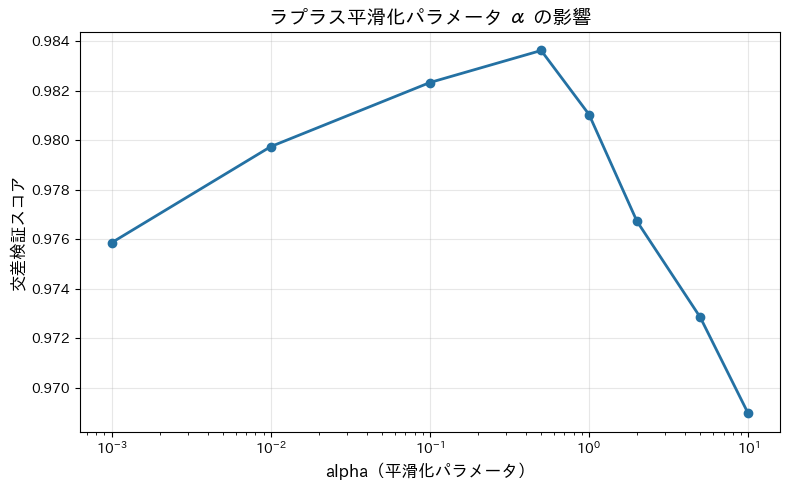

In [7]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import japanize_matplotlib

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
cv_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english')),
        ('nb', MultinomialNB(alpha=alpha))
    ])
    scores = cross_val_score(pipe, train_data.data, train_data.target, cv=5)
    cv_scores.append(scores.mean())
    print(f"alpha = {alpha:6.3f}  →  CV スコア = {scores.mean():.4f} ± {scores.std():.4f}")

# プロット
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alphas, cv_scores, 'o-', color='#2471A3', linewidth=2, markersize=6)
ax.set_xscale('log')
ax.set_xlabel('alpha（平滑化パラメータ）', fontsize=12)
ax.set_ylabel('交差検証スコア', fontsize=12)
ax.set_title('ラプラス平滑化パラメータ α の影響', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nb_alpha_tuning.png', dpi=150)
plt.show()


## 決定境界の可視化（ガウシアンナイーブベイズ）

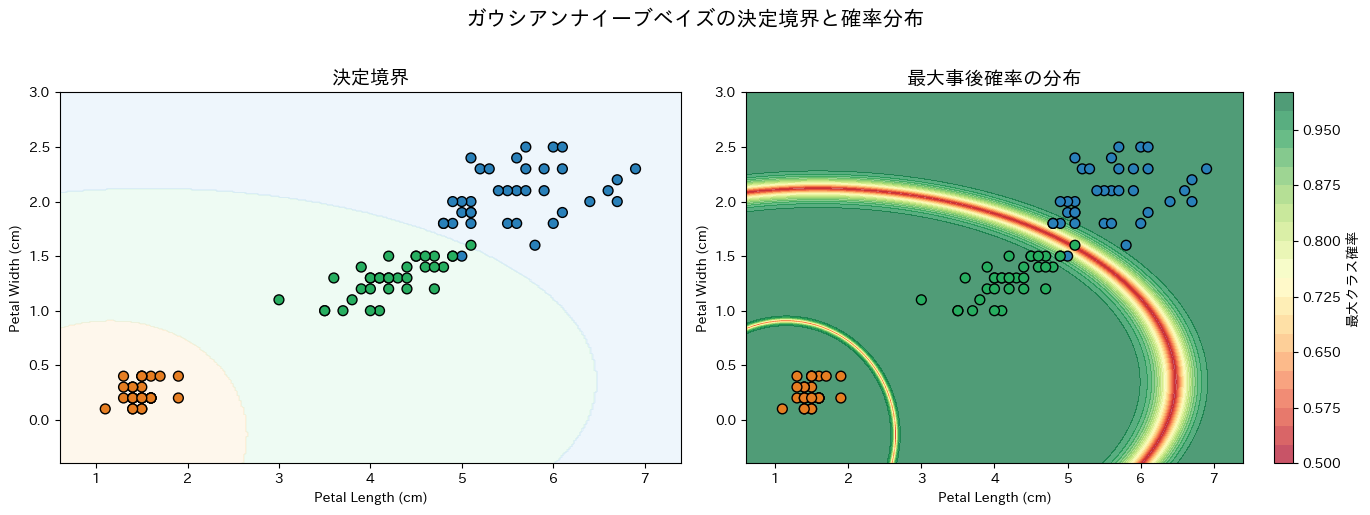

In [8]:
from matplotlib.colors import ListedColormap

# 2 特徴量に限定
X_vis = iris.data[:, 2:4]
y_vis = iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X_vis, y_vis, test_size=0.3, random_state=42, stratify=y_vis
)

gnb_vis = GaussianNB()
gnb_vis.fit(X_tr, y_tr)

x_min, x_max = X_tr[:, 0].min() - 0.5, X_tr[:, 0].max() + 0.5
y_min, y_max = X_tr[:, 1].min() - 0.5, X_tr[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
Z = gnb_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 確率の等高線も描画
Z_prob = gnb_vis.predict_proba(
    np.c_[xx.ravel(), yy.ravel()]
).max(axis=1).reshape(xx.shape)

cmap_bg = ListedColormap(['#FDEBD0', '#D5F5E3', '#D6EAF8'])
cmap_pt = ListedColormap(['#E67E22', '#27AE60', '#2980B9'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：クラス境界
axes[0].contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
axes[0].scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=cmap_pt,
                edgecolors='k', s=50)
axes[0].set_title('決定境界', fontsize=14)
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# 右：予測確率の等高線
cf = axes[1].contourf(xx, yy, Z_prob, levels=20, cmap='RdYlGn', alpha=0.7)
axes[1].scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=cmap_pt,
                edgecolors='k', s=50)
axes[1].set_title('最大事後確率の分布', fontsize=14)
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
plt.colorbar(cf, ax=axes[1], label='最大クラス確率')

plt.suptitle('ガウシアンナイーブベイズの決定境界と確率分布', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('nb_decision_boundary.png', dpi=150)
plt.show()


## バリエーション間の性能比較

In [9]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.preprocessing import KBinsDiscretizer

# Iris データで 3 種類のナイーブベイズを比較
print("=== Iris データセットでのナイーブベイズ比較 ===\n")

# 1. ガウシアン（連続値をそのまま使用）
gnb = GaussianNB()
scores_g = cross_val_score(gnb, X, y, cv=5)
print(f"GaussianNB      : {scores_g.mean():.4f} ± {scores_g.std():.4f}")

# 2. 多項（連続値を非負に変換して使用）
from sklearn.preprocessing import MinMaxScaler
X_mm = MinMaxScaler().fit_transform(X)
mnb = MultinomialNB()
scores_m = cross_val_score(mnb, X_mm, y, cv=5)
print(f"MultinomialNB   : {scores_m.mean():.4f} ± {scores_m.std():.4f}")

# 3. ベルヌーイ（二値化して使用）
bnb = BernoulliNB()
kbd = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile')
X_bin = kbd.fit_transform(X)
scores_b = cross_val_score(bnb, X_bin, y, cv=5)
print(f"BernoulliNB     : {scores_b.mean():.4f} ± {scores_b.std():.4f}")

# → 連続値データにはガウシアンが最適
# → テキストデータには多項 or ベルヌーイが最適


=== Iris データセットでのナイーブベイズ比較 ===

GaussianNB      : 0.9533 ± 0.0267
MultinomialNB   : 0.7933 ± 0.0490
BernoulliNB     : 0.7733 ± 0.0490


## 他の分類器との速度比較

In [10]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification

# 大規模データを生成
X_large, y_large = make_classification(
    n_samples=100000, n_features=50, n_informative=20,
    n_classes=5, random_state=42
)
X_lg_tr, X_lg_te, y_lg_tr, y_lg_te = train_test_split(
    X_large, y_large, test_size=0.3, random_state=42
)

models = {
    'GaussianNB':           GaussianNB(),
    'LogisticRegression':   LogisticRegression(max_iter=200),
    'DecisionTree':         DecisionTreeClassifier(max_depth=10),
    'k-NN (k=5)':           KNeighborsClassifier(n_neighbors=5),
}

print(f"データサイズ: 訓練={X_lg_tr.shape[0]:,}, テスト={X_lg_te.shape[0]:,}, "
      f"特徴量={X_lg_tr.shape[1]}\n")
print(f"{'モデル':<24s}  {'学習時間':>10s}  {'予測時間':>10s}  {'正解率':>8s}")
print("-" * 60)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_lg_tr, y_lg_tr)
    t_fit = time.time() - t0

    t0 = time.time()
    y_lg_pred = model.predict(X_lg_te)
    t_pred = time.time() - t0

    acc = accuracy_score(y_lg_te, y_lg_pred)
    print(f"{name:<24s}  {t_fit:>9.4f}s  {t_pred:>9.4f}s  {acc:>7.4f}")

# → ナイーブベイズは学習・予測ともに最速クラス


データサイズ: 訓練=70,000, テスト=30,000, 特徴量=50

モデル                             学習時間        予測時間       正解率
------------------------------------------------------------
GaussianNB                   0.0799s     0.0587s   0.6005
LogisticRegression           6.2703s     0.0207s   0.5925
DecisionTree                 8.3394s     0.0070s   0.6360
k-NN (k=5)                   0.0048s    15.8378s   0.9252
